In [1]:
import dataloader
import matplotlib.pyplot as plt
import numpy as np
import random

from transformers import ClapProcessor, ClapModel

In [2]:
raw_dataset = dataloader.get_dataset(None, 8192, sample_rate=48000)
print({ k: len(v) for k, v in raw_dataset.items() })

{'Cat': 242, 'BackgroundSounds': 8192, 'Siren': 2363, 'Noise': 1950, 'Bell': 702, 'Crow': 621, 'Horn': 1146, 'Engine': 5845, 'CarDoor': 452, 'BirdChirp': 1299, 'VehicleExhaust': 292, 'Sneezing': 154, 'GunNoise': 2448, 'Aircraft': 1118, 'Unknown': 293, 'Insects': 1986, 'Dog': 2767, 'Rooster': 403, 'Scream': 36, 'Beeping': 98, 'Skateboarding': 76, 'Drums': 6193, 'Sheep': 191, 'Clapping': 546, 'Gunshot': 8, 'Wind': 1408, 'Laughing': 216, 'Whistle': 21, 'Basketball': 752, 'GlassBreak': 982, 'HandSaw': 331, 'Train': 895, 'Coughing': 734, 'Thunder': 488, 'Frog': 3608, 'Whistling': 22, 'PowerTool': 1536, 'Cow': 168, 'Jackhammer': 2882}


In [3]:
class CLAPEncoder:
    def __init__(self):
        self.model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(0)
        self.processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

    def forward(self, x: np.ndarray, sample_rate: int) -> np.ndarray:
        """
        Forward pass through the CLAP model.
        """
        inputs = self.processor(audios=[x], return_tensors="pt", sampling_rate=sample_rate, padding=True).to(0)
        audio_embed = self.model.get_audio_features(**inputs)
        audio_embed = audio_embed.cpu().detach().numpy()
        # Flatten to 1D (512,) to match other encoders
        return audio_embed.squeeze()


In [63]:
class_count = 15
sub_classes = dict(random.sample(list(raw_dataset.items()), class_count))
print({ k: len(v) for k, v in sub_classes.items() })

{'Engine': 5845, 'Aircraft': 1118, 'Beeping': 98, 'Noise': 1950, 'GunNoise': 2448, 'Dog': 2767, 'Frog': 3608, 'Clapping': 546, 'Cow': 168, 'Coughing': 734, 'Train': 895, 'Insects': 1986, 'GlassBreak': 982, 'Cat': 242, 'Scream': 36}


In [4]:
# Filter to the classes we use in the main tests
desired_classes = ['Aircraft', 'Cow', 'Frog', 'Rooster', 'Sheep', 'Thunder']

sub_classes = {k: v for k, v in raw_dataset.items() if k in desired_classes}

print("Filtered dataset classes:", {k: len(v) for k, v in sub_classes.items()})

Filtered dataset classes: {'Aircraft': 1118, 'Rooster': 403, 'Sheep': 191, 'Thunder': 488, 'Frog': 3608, 'Cow': 168}


In [8]:
min_class_size = min(len(v) for v in sub_classes.values())
sub_classes = {k: v[:min_class_size] for k, v in sub_classes.items()}
print("Sub-classes after balancing:", { k: len(v) for k, v in sub_classes.items() })

Sub-classes after balancing: {'Aircraft': 168, 'Rooster': 168, 'Sheep': 168, 'Thunder': 168, 'Frog': 168, 'Cow': 168}


In [11]:
desired_size = 20
sub_classes = {k: v[:desired_size] for k, v in sub_classes.items()}
print("Sub-classes after limiting to desired size:", { k: len(v) for k, v in sub_classes.items() })

Sub-classes after limiting to desired size: {'Aircraft': 20, 'Rooster': 20, 'Sheep': 20, 'Thunder': 20, 'Frog': 20, 'Cow': 20}


In [49]:
example = sub_classes[list(sub_classes.keys())[0]][0]
print("Example audio shape:", example.shape)

Example audio shape: (48000,)


In [5]:
clap_encoder = CLAPEncoder()

In [12]:
# Encoding the audio data
encoded_data = {}
for class_name, audio_files in sub_classes.items():
    encoded_data[class_name] = []
    for audio_file in audio_files:
        audio_embedding = clap_encoder.forward(audio_file, sample_rate=48000)
        encoded_data[class_name].append(audio_embedding)

In [13]:
print("Encoded data:", { k: len(v) for k, v in encoded_data.items() })
print("Example embedding shape:", next(iter(encoded_data.values()))[0].shape)

Encoded data: {'Aircraft': 20, 'Rooster': 20, 'Sheep': 20, 'Thunder': 20, 'Frog': 20, 'Cow': 20}
Example embedding shape: (512,)


# PCA

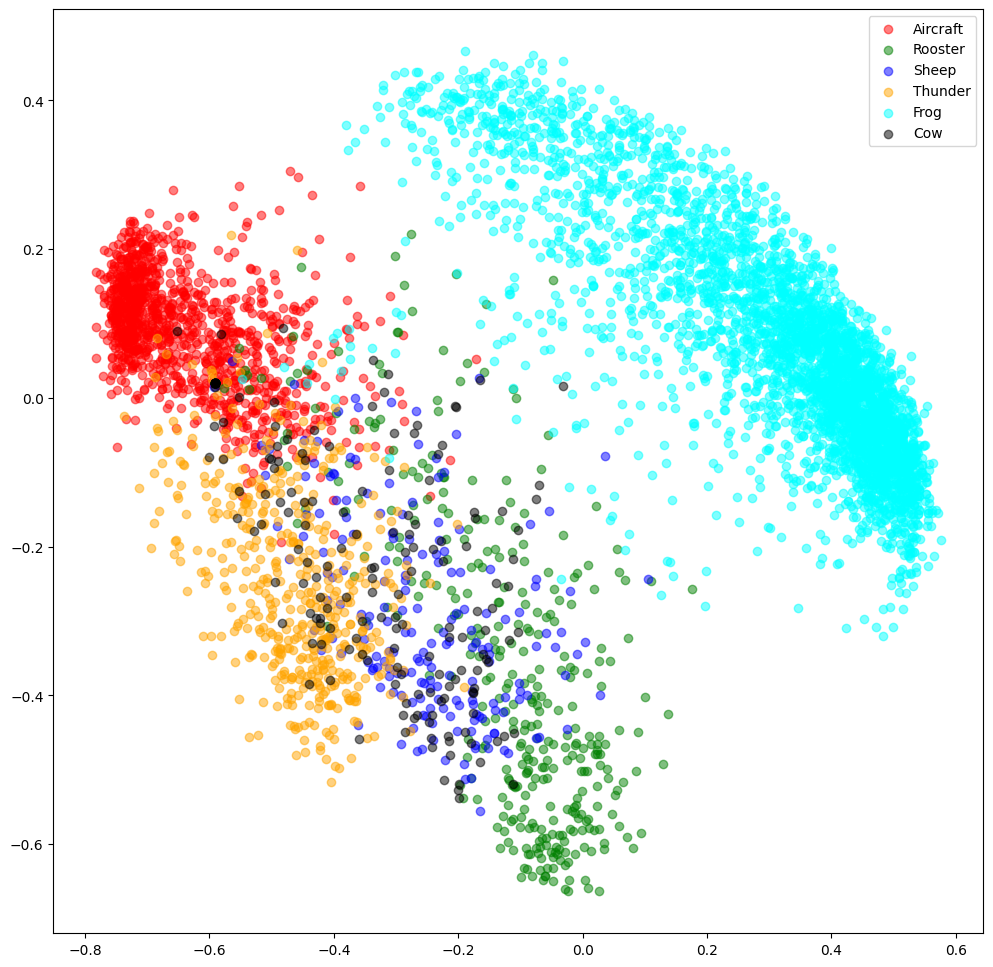

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca.fit_transform([x for xs in encoded_data.values() for x in xs])
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot()
labels = list(encoded_data.keys())
colors = ['red', 'green', 'blue', 'orange', 'cyan', 'black', 'yellow', 'purple', 'pink', 'brown', 'gray', 'lime', 'teal', 'magenta', 'olive']
for label, values in { k: pca.transform(v) for k, v in encoded_data.items() }.items():
    idx = labels.index(label)
    ax.scatter(*values.T, color = colors[idx], alpha = 0.5, label = label)
plt.legend()

# t-SNE

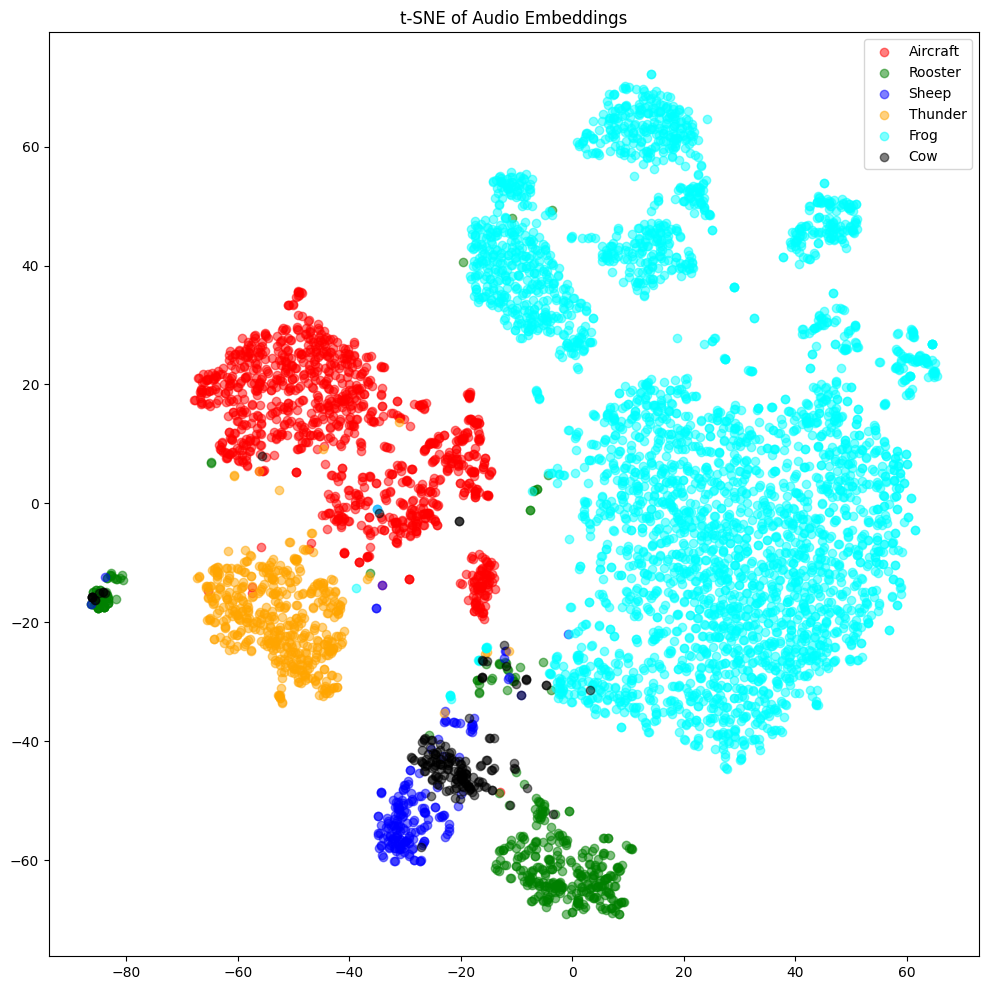

In [9]:
from sklearn.manifold import TSNE

# Flatten all embeddings for t-SNE
all_embeddings = [x for xs in encoded_data.values() for x in xs]
labels = list(encoded_data.keys())
label_indices = []
for idx, (label, xs) in enumerate(encoded_data.items()):
    label_indices.extend([idx] * len(xs))

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(np.stack(all_embeddings))

# Plot t-SNE results
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot()
colors = ['red', 'green', 'blue', 'orange', 'cyan', 'black', 'yellow', 'purple', 'pink', 'brown', 'gray', 'lime', 'teal', 'magenta', 'olive']
for idx, label in enumerate(labels):
    indices = [i for i, l in enumerate(label_indices) if l == idx]
    ax.scatter(tsne_results[indices, 0], tsne_results[indices, 1], color=colors[idx], alpha=0.5, label=label)
plt.legend()
plt.title("t-SNE of Audio Embeddings")
plt.show()

# UMAP

In [17]:
# Check embeddings before UMAP
all_embeddings = [x for xs in encoded_data.values() for x in xs]
all_labels = [label for label, xs in encoded_data.items() for _ in xs]
embeddings_array = np.stack(all_embeddings)
print("Embeddings shape:", embeddings_array.shape)
print("Any NaN:", np.isnan(embeddings_array).any())
print("Any Inf:", np.isinf(embeddings_array).any())

Embeddings shape: (120, 512)
Any NaN: False
Any Inf: False


In [15]:
from umap import UMAP

# Fit and transform with UMAP once
umap = UMAP(n_components=2, n_jobs=1)
umap_points = umap.fit_transform(all_embeddings, n_jobs=1)
print("UMAP points shape:", umap_points.shape)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP points shape: (120, 2)


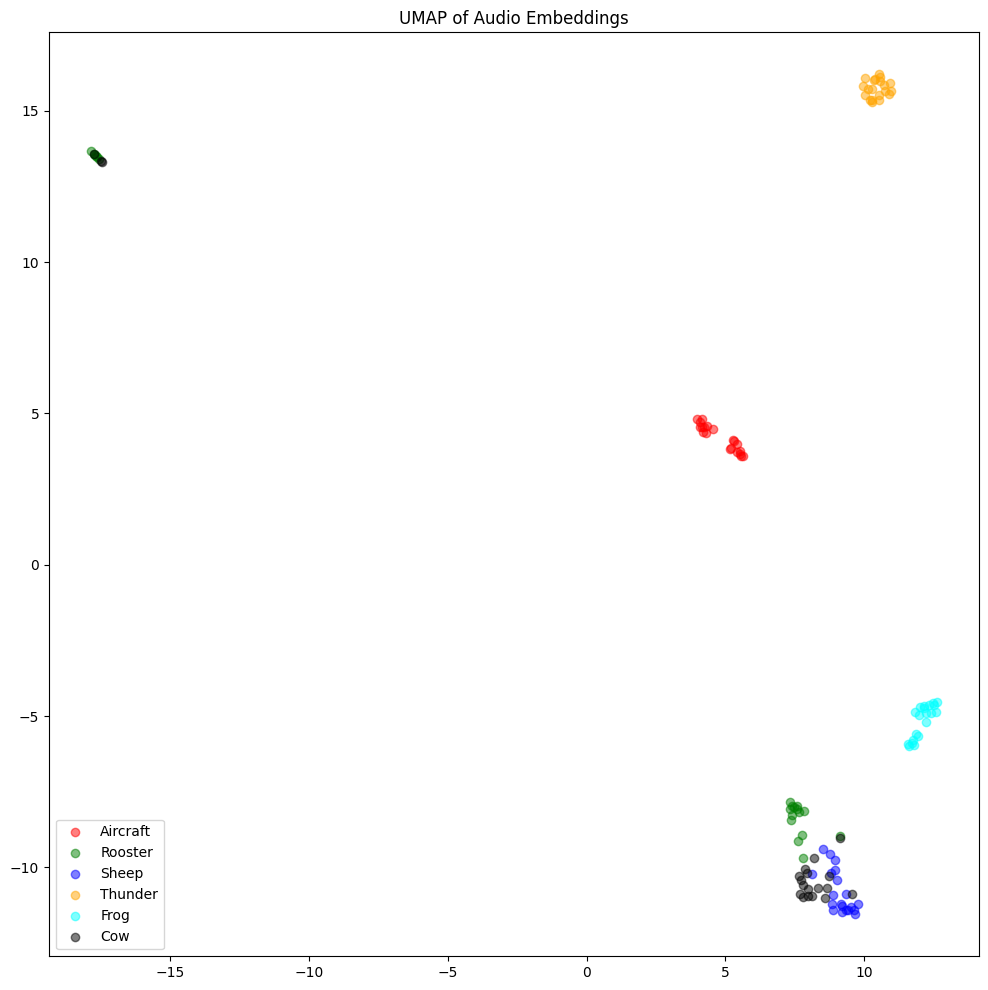

In [18]:

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot()
labels = list(sub_classes.keys())
colors = ['red', 'green', 'blue', 'orange', 'cyan', 'black', 'yellow', 'purple', 'pink', 'brown', 'gray', 'lime', 'teal', 'magenta', 'olive']

for idx, label in enumerate(labels):
    indices = [i for i, l in enumerate(all_labels) if l == label]
    ax.scatter(umap_points[indices, 0], umap_points[indices, 1], color=colors[idx], alpha=0.5, label=label)

plt.legend()
plt.title("UMAP of Audio Embeddings")
plt.show()